In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
df = yf.download(['MARUTI.NS', 'BAJAJ-AUTO.NS', 'M&M.NS', '^CNXAUTO'], start='2014-01-01')['Close']
df.dropna()

[*********************100%***********************]  4 of 4 completed


Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,^CNXAUTO
Date,,,,
2014-01-01,1412.231201,423.806488,1594.060913,5292.649902
2014-01-02,1399.452515,418.486481,1598.037231,5253.549805
2014-01-03,1396.138184,402.459656,1625.327759,5194.899902
2014-01-06,1390.798218,400.291443,1633.550903,5204.799805
2014-01-07,1392.013184,403.733734,1667.935425,5209.700195
...,...,...,...,...
2026-04-06,8942.500000,3021.600098,12688.000000,24350.400391
2026-04-07,9049.500000,3006.600098,12798.000000,24373.300781
2026-04-08,9366.000000,3210.100098,13602.000000,26002.949219


# Log Returns

In [4]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

Ticker,BAJAJ-AUTO.NS,M&M.NS,MARUTI.NS,^CNXAUTO
Date,,,,
2014-01-02,-0.009090,-0.012632,0.002491,-0.007415
2014-01-03,-0.002371,-0.039050,0.016933,-0.011227
2014-01-06,-0.003832,-0.005402,0.005047,0.001904
2014-01-07,0.000873,0.008563,0.020830,0.000941
2014-01-08,0.014889,0.006072,-0.004480,0.008011
...,...,...,...,...
2026-04-06,0.020791,0.003282,0.004503,0.010766
2026-04-07,0.011894,-0.004977,0.008632,0.000940
2026-04-08,0.034377,0.065492,0.060928,0.064722


# Excess Returns

In [28]:
rf = 0.06/252
excess = log_returns.sub(rf, axis=0)

# Rollig CAP  Function (Alpha & Beta)

In [42]:
def rolling_capm(stock, market, window=252):
    betas = []
    alphas = []
    dates = stock.index[window:]

    for i in range(window, len(stock)):
        y = stock.iloc[i-window:i]
        x = sm.add_constant(market.iloc[i-window:i])

        res = sm.OLS(y, x).fit()
        betas.append(res.params.iloc[1])
        alphas.append(res.params.iloc[0] * 252)  # annualized

    return pd.DataFrame(
        {'Alpha': alphas, 'Beta': betas},
        index=dates)

# Rolling Alpha & Beta



In [47]:
capm = {
    s: rolling_capm(excess[s], excess['^CNXAUTO'])
    for s in ['BAJAJ-AUTO.NS', 'M&M.NS', 'MARUTI.NS']
}

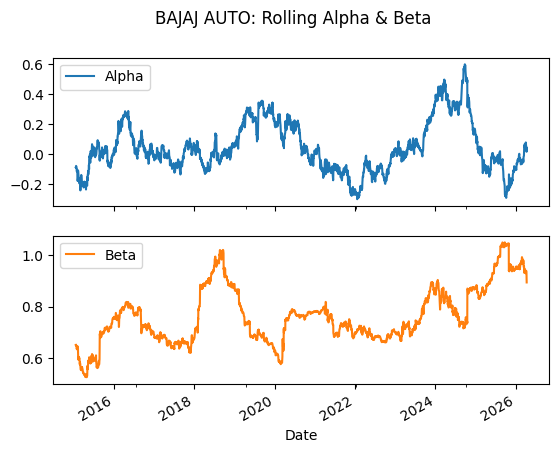

In [49]:
capm['BAJAJ-AUTO.NS'].plot(subplots=True, title='BAJAJ AUTO: Rolling Alpha & Beta')
plt.show()

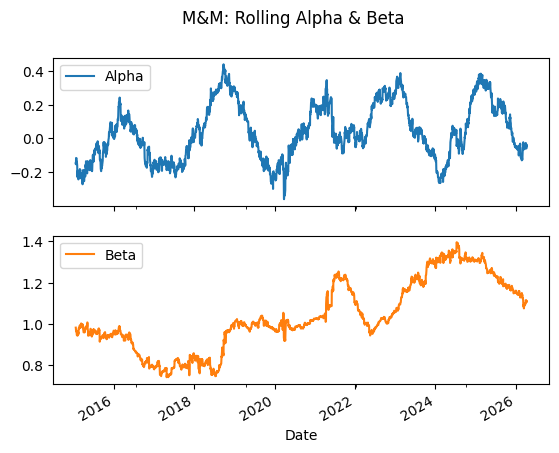

In [51]:
capm['M&M.NS'].plot(subplots=True, title='M&M: Rolling Alpha & Beta')
plt.show()

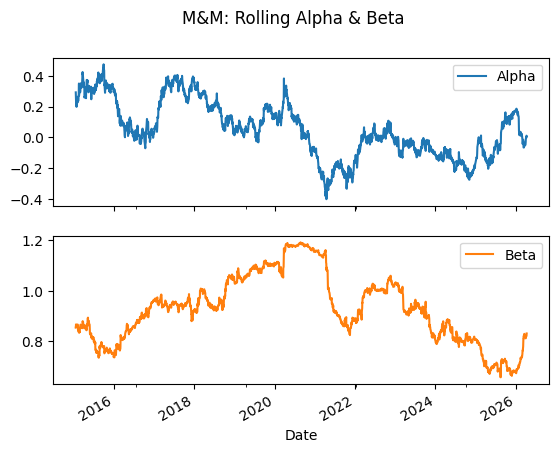

In [53]:
capm['MARUTI.NS'].plot(subplots=True, title='M&M: Rolling Alpha & Beta')
plt.show()

In [22]:
print(excess['M&M.NS'].equals(excess['^CNXAUTO']))

False


In [24]:
excess[['M&M.NS', '^CNXAUTO']].corr()

Ticker,M&M.NS,^CNXAUTO
Ticker,,
M&M.NS,1.000000,0.741935
^CNXAUTO,0.741935,1.000000


In [40]:
excess[['M&M.NS', '^CNXAUTO']].describe()

Ticker,M&M.NS,^CNXAUTO
count,2984.000000,2984.000000
mean,0.000386,0.000240
std,0.018859,0.013563
min,-0.097803,-0.149293
25%,-0.009927,-0.006470
50%,0.000308,0.000623
75%,0.010149,0.007292
max,0.155487,0.098759
